# Phase 2 — Predicting Negative Reviews: Logistic Regression vs Random Forest

**The question:** can we tell which customers are going to leave a **negative review** (1–2 stars) early enough for customer service to contact them *before* they write it?

**The two-stage design.** There are two moments when customer service can still act, and each may only use what is known at that moment (step 2.2 explains why):

| Stage | When | Who | Tool |
|---|---|---|---|
| **1** | The promised delivery date passes and the parcel has not arrived | Every late order | A simple rule: contact them all. Most late customers end up unhappy, so no model is needed. |
| **2** | The parcel is delivered | Every customer who has not reviewed yet | A model ranks orders by risk, and customer service contacts the riskiest 10%. |

Most of this notebook is about **Stage 2**: which model family ranks delivered orders best. Step 14 then scores both stages together on later orders.

**What this notebook does for Stage 2:** it compares two model families, plus a simple business rule as a benchmark. Each family starts from its **simplest version** and steps up in complexity, and every step has to prove it is worth it.

| | Model | Family | Version |
|---|---|---|---|
| R | "Flag the latest deliveries" rule | Benchmark | No model: rank orders by how late they arrived |
| A | Logistic Regression | Linear | Plain: no regularisation, no class weighting |
| B | Logistic Regression | Linear | Tuned |
| C | Decision Tree | Tree-based | A single tree, default settings |
| D | Random Forest | Tree-based | 200 trees, default settings (no tuning) |
| E | Random Forest | Tree-based | Tuned |

**Two design choices drive everything below:**

* **Time-based validation.** Models learn from **earlier orders** and are tested on **later orders**, as they would be in real use. Our Phase 1 literature review warns that random splits of time-ordered data cause temporal leakage and overestimate performance, and the professor lists it as a pitfall.
* **Top-10% precision decides the winner.** Customer service works a fixed daily contact list, so Phase 1 committed to judging the model on *"precision among its top-ranked orders"*. We rank orders by risk and ask: of the riskiest 10%, how many really leave a negative review?

**How to read this notebook.** Every step explains **what we are doing** and **why**, in plain English. A 📌 line quotes the course guidance behind a method choice. Every result is followed by **What this tells us**. Some steps also have a **Likely question** with an answer you can use to defend the approach.

**The steps**

1. Load the data
2. Build the modelling table, and split the problem into two stages
3. Split by time: learn from the past, test on the future
4. Prepare the inputs for the models
5. Meet the models and the benchmark rule
6. How we score models, cross-validation and tuning
7. Cross-validation results: pick the winner
8. The final exam: results on later orders, ROC and precision-recall curves, and train vs validation vs test
9. Does each step up in complexity help, and do the models beat the rule?
10. What do the models rely on?
11. Error analysis: where does the model go wrong?
12. How much would a random split have flattered the models?
13. Final comparison: tuned Logistic Regression vs tuned Random Forest
14. The whole system on later orders: Stage 1 rule + Stage 2 model
15. A note on the saved model files

The report write-up (problem statement and stakeholder, data cleaning, feature engineering, insights and limitations) is in [`docs/Phase2_Classification_Report_Sections.docx`](../docs/Phase2_Classification_Report_Sections.docx).

> **Runtime:** about 15–17 minutes on a 12-core laptop (16.9 minutes on the last run). Most of it is the Random Forest tuning in step 6 and cross-validation in step 7.

## Step 1. Load the data

**What we are doing:** loading two tables prepared and cleaned in Phase 1:

* `order_level.csv`: **one row per order**, with delivery dates, payment, customer location and the review score.
* `item_level.csv`: **one row per product inside an order**, with price, category and product size.

**Why:** both model families start from exactly the same, already-checked data, so any difference in results comes from the models themselves.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate, train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.classification_data import (
    DELIVERED_MODEL_FEATURES,
    DELIVERED_NUMERIC_FEATURES,
    TARGET_COLUMN,
    build_delivered_order_classification_dataset,
    split_delivered_order_features_target,
)
from src.classification_model import build_delivered_order_logistic_pipeline
from src.classification_tree_model import (
    build_delivered_order_decision_tree_pipeline,
    build_delivered_order_random_forest_pipeline,
)

RANDOM_SEED = 42
THRESHOLD = 0.50
TOP_SHARE = 0.10
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
notebook_started = time.perf_counter()

order_level = pd.read_csv(PROCESSED_DIR / "order_level.csv")
item_level = pd.read_csv(PROCESSED_DIR / "item_level.csv")

print(f"order_level: {order_level.shape[0]:,} rows × {order_level.shape[1]} columns")
print(f"item_level: {item_level.shape[0]:,} rows × {item_level.shape[1]} columns")
print(f"scikit-learn version: {sklearn.__version__}")

order_level: 99,441 rows × 36 columns
item_level: 112,650 rows × 20 columns
scikit-learn version: 1.9.1


## Step 2. Build the modelling table

**What we are doing:** turning the two tables into **one row per order**, with 21 input columns (the clues) and one answer column (the **target**):

* target = **1** if the review was 1–2 stars (negative)
* target = **0** if the review was 3–5 stars

We keep only orders that were **delivered**, have a **delivery date** and have a **review**. A model can only learn from orders whose outcome we know.

**Why only these inputs:** the models (Stage 2) make their prediction **right after delivery, before the review exists**. Delivery information (how late, how long it took) is allowed, because we know it at that moment. Step 2.1 shows that some customers review *before* delivery, and step 2.2 handles them separately. Anything from the review itself is not allowed. Using it would be **leakage**, like marking an exam with the answer sheet in view: the model would look brilliant in testing but could never work in real life. The team's code in `src/classification_data.py` enforces this, and stops with an error if the data breaks its rules.

> 📌 *"Do not use information that would only be known after the target event has already occurred."* (IT5006 project brief)
>
> 📌 *"Before modelling, list each candidate feature and confirm that it is known at the intended prediction point."* (IT5006 project brief)

In [2]:
delivered_at = pd.to_datetime(order_level["order_delivered_customer_date"], errors="coerce")
population_masks = [
    ("All orders", pd.Series(True, index=order_level.index)),
    ("Delivered status", order_level["order_status"].eq("delivered")),
    ("Delivery date present", delivered_at.notna()),
    ("Review recorded", order_level["review_score"].notna()),
]
eligible_so_far = pd.Series(True, index=order_level.index)
audit_rows = []
for stage, stage_mask in population_masks:
    eligible_so_far &= stage_mask
    audit_rows.append({"filter": stage, "orders_remaining": int(eligible_so_far.sum())})
display(pd.DataFrame(audit_rows))

classification_data = build_delivered_order_classification_dataset(order_level, item_level)
lookup = order_level.set_index("order_id").loc[classification_data["order_id"]]
classification_data["purchase_time"] = pd.to_datetime(lookup["order_purchase_timestamp"], format="mixed").to_numpy()

display(
    classification_data[TARGET_COLUMN]
    .value_counts()
    .rename(index={0: "Review 3–5 (target 0)", 1: "Negative review 1–2 (target 1)"})
    .rename("orders")
    .to_frame()
    .assign(share=lambda table: (table["orders"] / table["orders"].sum()).round(3))
)
display(pd.DataFrame({
    "input": DELIVERED_MODEL_FEATURES,
    "type": ["number" if name in DELIVERED_NUMERIC_FEATURES else "category" for name in DELIVERED_MODEL_FEATURES],
}))

assert classification_data["order_id"].is_unique
assert "order_id" not in DELIVERED_MODEL_FEATURES
assert not any(name.startswith("review_") for name in DELIVERED_MODEL_FEATURES)

,filter,orders_remaining
0,All orders,99441
1,Delivered status,96478
2,Delivery date present,96470
3,Review recorded,95824


,orders,share
is_negative_review,,
Review 3–5 (target 0),83552,0.872
Negative review 1–2 (target 1),12272,0.128


,input,type
0,item_count,number
1,order_item_value,number
2,order_freight_value,number
3,seller_count,number
4,payment_total,number
5,payment_count,number
6,max_installments,number
7,freight_share,number
8,delivery_days,number
9,days_early,number


### What this tells us

* **95,824 orders** can be used to train and test the models.
* Only **12.8% (12,272) are negative reviews**, roughly 1 in 7. This is called **class imbalance**, and it matters a lot. A lazy "model" that always says "not negative" would be right 87% of the time and still be useless, because it never finds an unhappy customer. That is why this notebook **never judges a model on accuracy alone**.
* The `assert` lines at the end of the cell prove in code that no order ID and no review field is used as an input.

### 2.1 Some reviews are written before delivery

**What we are checking:** our models predict at delivery, which assumes the review comes *after* delivery. In Olist, though, the review request can go out around the **promised** delivery date even if the parcel has not arrived yet. The cell below counts how often the review was actually written **before** the order was delivered, and how often those reviews are negative.

**Why it matters:** for those orders, the review already exists when the parcel arrives, so a call at delivery comes too late to help. Their delivery inputs (`delivery_days`, `days_early`, `late_delivery_flag`) also describe a delivery that happened *after* the review, which is a form of **leakage**: information from after the outcome. Kapoor & Narayanan (2023), from our Phase 1 review, show that leakage can make a model, and especially a complex one, look better than it really is.

In [3]:
reviewed_at = pd.to_datetime(lookup["review_answer_timestamp"], format="mixed").to_numpy()
delivered = pd.to_datetime(lookup["order_delivered_customer_date"], format="mixed").to_numpy()
promised_day_ends = (pd.to_datetime(lookup["order_estimated_delivery_date"], format="mixed") + pd.Timedelta(days=1)).to_numpy()
classification_data["reviewed_before_delivery"] = reviewed_at < delivered
classification_data["reviewed_before_promised_day_ended"] = reviewed_at < promised_day_ends

is_late = classification_data["late_delivery_flag"].eq(1)
is_negative = classification_data[TARGET_COLUMN].eq(1)
before_delivery = classification_data["reviewed_before_delivery"]
print(f"Orders reviewed before delivery: {before_delivery.sum():,} ({before_delivery.mean():.1%} of all orders)")
print(f"  share of LATE orders reviewed before delivery: {before_delivery[is_late].mean():.1%}")
print(f"  share of on-time or early orders reviewed before delivery: {before_delivery[~is_late].mean():.1%}")
print(f"  negative-review rate among them: {is_negative[before_delivery].mean():.1%} (vs {is_negative[~before_delivery].mean():.1%} for the rest)")
print(f"  share of ALL negative reviews that were written before delivery: {before_delivery[is_negative].mean():.1%}")

print("\nNegative-review rate by delivery outcome and by when the review was written")
display(
    classification_data.assign(
        delivery=np.where(is_late, "late", "on time or early"),
        review_written=np.where(before_delivery, "before delivery", "after delivery"),
    )
    .pivot_table(index="delivery", columns="review_written", values=TARGET_COLUMN, aggfunc=["size", "mean"])
    .rename(columns={"size": "orders", "mean": "negative-review rate"}, level=0)
    .round(3)
)

Orders reviewed before delivery: 4,653 (4.9% of all orders)
  share of LATE orders reviewed before delivery: 70.1%
  share of on-time or early orders reviewed before delivery: 0.2%
  negative-review rate among them: 78.3% (vs 9.5% for the rest)
  share of ALL negative reviews that were written before delivery: 29.7%

Negative-review rate by delivery outcome and by when the review was written


orders                 negative-review rate  \
review_written   after delivery before delivery       after delivery   
delivery                                                               
late                       1908            4473                0.194   
on time or early          89263             180                0.093   

                                  
review_written   before delivery  
delivery                          
late                       0.808  
on time or early           0.172

### What this tells us

* **4,653 orders (4.9%) were reviewed before they were delivered**, and almost all of them were late: **70.1% of late orders** were reviewed before delivery, against 0.2% of on-time or early orders.
* **These reviews are mostly negative (78.3%, against 9.5% for the rest)**, and they make up **29.7% of all negative reviews**. Customers who are still waiting for their parcel write "where is my order?" reviews.
* **Lateness is a real risk on its own.** Among customers who reviewed *after* delivery, late orders still got twice as many negative reviews as on-time ones (19.4% vs 9.3%). So lateness is a genuine signal, but much weaker than the 80.8% among those who reviewed while waiting.
* **What this means:** a model that predicts at delivery cannot help customers who have already reviewed, yet it would count them as easy successes. Step 2.2 gives these customers their own, earlier moment to act.

### 2.2 The two-stage design

**What we are doing:** splitting the problem into the two moments when customer service can still act, each using only what is known at that moment.

| | Stage 1 | Stage 2 |
|---|---|---|
| **When** | The promised delivery date has passed and the parcel has not arrived | The parcel has just been delivered |
| **Known at that moment** | "This order is late", plus the order's details | Everything the models use, including the actual delivery time |
| **Who is contacted** | Every late order | The riskiest 10% of delivered orders whose customer has not reviewed yet |
| **Tool** | A simple rule, no model | The models compared in this notebook |

**Why Stage 1 is a rule, not a model:** a model earns its place when the answer is not obvious. For late orders it is: the cell below shows that most of them end in a negative review. A rule is also free to run, easy to explain, and does not use up one of the project's 2–3 model families.

**Why the models (Stage 2) leave out customers who reviewed before delivery:** at the delivery-time prediction point their review already exists, so they cannot be helped, and their delivery inputs come from after the outcome (step 2.1). Late orders reviewed *after* delivery stay in Stage 2: for them, lateness is a fair input.

> 📌 *"Check for leakage first by identifying which columns are known before the prediction point."* (IT5006 project brief)

In [4]:
all_delivered = classification_data.copy()
late = all_delivered["late_delivery_flag"].eq(1)
negative = all_delivered[TARGET_COLUMN].eq(1)
too_late_for_stage1 = late & all_delivered["reviewed_before_promised_day_ended"]
print("Stage 1, at the promised date: flag every order that has not arrived (no model)")
print(f"  flags {late.sum():,} late orders ({late.mean():.1%} of all orders)")
print(f"  {negative[late].mean():.1%} of them got a negative review: {negative[late].sum():,} of all {negative.sum():,} "
      f"negative reviews ({negative[late].sum() / negative.sum():.1%})")
print(f"  {too_late_for_stage1.sum():,} late orders were reviewed before their promised day ended, so even Stage 1 is too late for them")

classification_data = all_delivered.loc[~all_delivered["reviewed_before_delivery"]].reset_index(drop=True)
print("\nStage 2, at delivery: the models score every order whose customer has not reviewed yet")
print(f"  {len(classification_data):,} orders ({len(all_delivered) - len(classification_data):,} reviewed before delivery left out); "
      f"negative-review rate {classification_data[TARGET_COLUMN].mean():.1%}; delivered late {classification_data['late_delivery_flag'].mean():.1%}")
assert not classification_data["reviewed_before_delivery"].any()

Stage 1, at the promised date: flag every order that has not arrived (no model)
  flags 6,381 late orders (6.7% of all orders)
  62.4% of them got a negative review: 3,983 of all 12,272 negative reviews (32.5%)
  44 late orders were reviewed before their promised day ended, so even Stage 1 is too late for them

Stage 2, at delivery: the models score every order whose customer has not reviewed yet
  91,171 orders (4,653 reviewed before delivery left out); negative-review rate 9.5%; delivered late 2.1%


### What this tells us

* **Stage 1 is a strong rule.** It flags **6,381 late orders** (6.7% of all orders), and **62.4%** of them got a negative review. Together they hold **3,983 of the 12,272 negative reviews (32.5%)**. This matches Phase 1's finding that fixing delivery alone addresses under a third of bad reviews.
* **Stage 1 comes in time for nearly everyone it flags.** Only 44 late orders were reviewed before their promised day had even ended.
* **Stage 2 has a harder job.** It covers **91,171 orders**, the 4,653 orders reviewed before delivery being left out. Only **9.5%** of them got a negative review (about 1 in 10.5), and only 2.1% were late. So the models must find unhappy customers mostly among orders that arrived on time, where the signal is weaker. Expect lower scores than a model that also counted the easy pre-delivery reviews.
* **From here to step 13, "the data" means the Stage 2 orders.** Step 14 brings both stages back together.

## Step 3. Split by time: learn from the past, test on the future

**What we are doing:** sorting the orders by **purchase date**. The **earliest 80%** become the training set, and the **latest 20%** become the test set, the "final exam".

**Why:** in real use, a model is trained on past orders and used on future ones. If we mixed old and new orders randomly, the model could learn from orders placed *after* the ones it is tested on, a form of peeking into the future that makes it look better than it really is. Our Phase 1 literature review warns that random splits of time-ordered data cause exactly this **temporal leakage** and overestimate performance. Step 12 measures how big the effect is here.

> 📌 *"We only evaluate on test set ONCE - after all model selection is complete. This prevents "peeking" at test data."* (IT5006 T08 tutorial, *Classification Models*)

**The trade-off:** a time split cannot force both parts to have the same share of negative reviews, because that share changes over time. The table below shows how it moves from quarter to quarter.

**Likely question:** *"The brief says to use stratified splits for imbalanced data. Why not here?"* (The brief: *"Use stratified splits for imbalanced classification targets."*) **Answer:** stratifying means shuffling orders across time, which reintroduces the temporal leakage. We keep the imbalance under control in other ways: metrics that focus on the negative reviews (step 6), and class weighting as a tuning option (step 5).

In [5]:
classification_data = classification_data.sort_values("purchase_time", kind="stable").reset_index(drop=True)
X, y = split_delivered_order_features_target(classification_data)
purchase_time = classification_data["purchase_time"]

n_train = int(len(X) * 0.80)
X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

for label, part, target, times in [
    ("Training set", X_train, y_train, purchase_time.iloc[:n_train]),
    ("Test set", X_test, y_test, purchase_time.iloc[n_train:]),
]:
    print(f"{label}: {len(part):,} orders, {times.min().date()} to {times.max().date()}; "
          f"negative-review rate {target.mean():.1%}; delivered late {part['late_delivery_flag'].mean():.1%}")
print(f"Negative : not-negative ratio in training = 1 : {(y_train == 0).sum() / (y_train == 1).sum():.1f}")

print("\nBy purchase quarter")
display(
    pd.DataFrame({
        "quarter": purchase_time.dt.to_period("Q").astype(str),
        "negative": y.to_numpy(),
        "late": X["late_delivery_flag"].to_numpy(),
    })
    .groupby("quarter")
    .agg(orders=("negative", "size"), negative_rate=("negative", "mean"), late_share=("late", "mean"))
    .round(3)
    .T
)

Training set: 72,936 orders, 2016-10-03 to 2018-05-31; negative-review rate 9.7%; delivered late 2.2%
Test set: 18,235 orders, 2018-05-31 to 2018-08-29; negative-review rate 8.5%; delivered late 1.6%
Negative : not-negative ratio in training = 1 : 9.3

By purchase quarter


quarter,2016Q4,2017Q1,2017Q2,2017Q3,2017Q4,2018Q1,2018Q2,2018Q3
orders,259.000,4766.000,8681.000,11812.000,16057.000,18433.000,19026.000,12137.000
negative_rate,0.158,0.096,0.095,0.084,0.100,0.108,0.092,0.080
late_share,0.004,0.009,0.014,0.011,0.026,0.034,0.016,0.023


### What this tells us

* **Training set:** 72,936 orders bought between 3 October 2016 and 31 May 2018. **Test set:** 18,235 orders bought between 31 May and 29 August 2018.
* **The test period is a little calmer.** It has fewer negative reviews (8.5% vs 9.7%) and fewer late deliveries (1.6% vs 2.2%). The quarterly table shows the negative-review rate staying between 8.0% and 10.8% from 2017 onwards (2016's 259 orders are too few to read), with late deliveries peaking at 3.4% in early 2018.
* **This matters for reading the scores later.** With fewer unhappy customers in the test period, precision will be a little lower there than in training, even for an equally good model. That is what the future actually looked like, not a flaw of the split.
* **Imbalance:** about 1 negative review for every 9.3 others in training.

## Step 4. Prepare the inputs for the models

**What we are doing:** models can only work with numbers and cannot handle gaps. Three things happen automatically inside each model's **pipeline**:

1. **Gaps are filled.** A missing number gets the **median** (the middle value); a missing category gets the **most common value**. The table below shows how few gaps there are.
2. **Categories become 0/1 columns** (one-hot encoding). For example, `customer_state` becomes one column per state, such as "is the customer in SP? 1 or 0". This turns the 21 inputs into many more model columns.
3. **Numbers are rescaled, for Logistic Regression only.** Rescaling stops a column measured in grams from drowning out one measured in days. Tree-based models do not need it, because a tree only asks questions like "is it more than 20 days?".

**Why inside a pipeline:** the fill-in values and the scaling are learned **from the training data only**, and the same steps are then applied to new orders. Nothing about the test set can leak into training.

> 📌 *"Use pipelines to prevent leakage, especially by keeping preprocessing inside cross-validation folds."* (IT5006 project brief)
>
> 📌 *"Preprocessing parameters (mean, std for scaling) must be computed on TRAINING data only"* (IT5006 T08 tutorial, *Classification Models*)

In [6]:
missing = X_train.isna().sum()
missing = missing[missing > 0]
display(pd.DataFrame({
    "missing_orders": missing,
    "missing_percent": (missing / len(X_train) * 100).round(2),
    "filled_with": ["median" if name in DELIVERED_NUMERIC_FEATURES else "most common value" for name in missing.index],
}))

encoded_columns = (
    build_delivered_order_logistic_pipeline(random_state=RANDOM_SEED)
    .named_steps["preprocessor"]
    .fit(X_train)
    .get_feature_names_out()
)
print(f"{len(DELIVERED_MODEL_FEATURES)} inputs → {len(encoded_columns)} model columns after turning categories into 0/1 columns")

,missing_orders,missing_percent,filled_with
product_weight_g_mean,16,0.02,median
product_volume_cm3_mean,16,0.02,median
product_photos_qty_mean,1166,1.60,median
primary_product_category,1166,1.60,most common value


21 inputs → 165 model columns after turning categories into 0/1 columns


### What this tells us

* Only 4 of the 21 inputs have any gaps, and the biggest gap is **1.60%** of training orders (product photos and product category, missing for the same orders). Simple filling is enough, and no orders need to be thrown away.
* The 21 inputs become **165 model columns**. The latest purchase months (June–August 2018) only appear in the test period, so the model has never seen them and simply ignores them.

## Step 5. Meet the models and the benchmark rule

### R — the benchmark rule: "flag the latest deliveries"

Before building any model, we set a **simple business rule** that every model must beat. It ranks orders by **how late they arrived** against the promised date, latest first. With the 0.50 cut-off it flags every late order. It needs no training at all.

**Why:** our Phase 1 literature review recommends benchmarking against the platform's own delivery promise, and Kapoor & Narayanan (2023) show that simple baselines are the honest test of whether a complex model adds anything. Phase 1 also found that satisfaction drops sharply from the very first day an order is late. So if a model cannot beat "contact the latest deliveries", it is not worth building.

In this notebook the rule is a **benchmark** for Stage 2. It is not the Stage 1 rule: Stage 1 contacts late orders at the promised date, before they are delivered.

> 📌 *"A model is only useful if it beats simple heuristics"* (IT5006 T08 tutorial, *Classification Models*)

### Family 1 — Logistic Regression: a weighted checklist

Logistic Regression gives **every input a weight**. For each order it adds up *weight × value* across all inputs, then squeezes the total into a **risk score between 0 and 1**. A positive weight pushes the risk up; a negative weight pushes it down.

* **Strength:** simple, fast, and easy to explain ("late delivery raises the odds of a bad review by X%").
* **Weakness:** each input can only push in one fixed direction. It cannot easily learn "risk only jumps once an order is late", or "late *and* from several sellers is especially bad".

**A. Plain Logistic Regression** is the simplest version: no **regularisation** (nothing holds the weights back, set with `C = infinity`) and no class weighting. scikit-learn's default is *not* plain, because it already holds the weights back a little (`C = 1`). So we switch that off to get a true baseline. **B** is the tuned version (step 6).

### Family 2 — Decision Tree → Random Forest

**C. A single decision tree** is a flowchart learned from data. It asks yes/no questions about an order, such as *"Was it late?" → "Did it take more than 20 days?"*. Each end-point holds the share of negative reviews among the training orders that landed there. It is the simplest tree-based model and the family's baseline. Left to grow freely, one tree tends to **memorise** the training orders (**overfitting**).

**D. A Random Forest** grows **200 different trees**. Each tree sees a random sample of orders and, at each question, may only choose from a random handful of inputs. The forest's risk score is the **average of all 200 trees**. Individual trees make different mistakes, and averaging cancels much of that noise. **E** is the tuned forest (step 6).

* **Strength:** learns thresholds and combinations automatically.
* **Weakness:** harder to explain, slower to train, and a much bigger model file.

### The class-imbalance option: class weighting

Because only about 1 in 10 Stage 2 orders is negative, a model left alone learns to be cautious. **Class weighting** tells the model that a missed negative review counts about **9× as much** as a happy customer wrongly flagged. This is **cost-sensitive learning**, which Kandula et al. (2021) found effective. We do not resample the data, because van den Goorbergh et al. (2022) show that resampling distorts the risk scores without improving ranking. Whether to use class weighting is **one of the settings we tune**.

> 📌 *"Consider class weights or resampling where appropriate, and discuss imbalance explicitly in the report."* (IT5006 project brief)

### Simplest version first

Every model has **settings** (called **hyperparameters**) that are chosen *before* training, like the knobs on an oven. **Tuning** means trying many settings and keeping the best (step 6).

**Why start simple:** the project brief says to start with the simplest version in each family as a **baseline**, and that each more complex version must **prove** it is better. Step 9 checks every step up: A → B, C → D, D → E, and the best model against the rule.

> 📌 *"Start with the simplest variant in each family as a baseline."* (IT5006 project brief)
>
> 📌 *"Any more complex variant must demonstrate improvement over the baseline."* (IT5006 project brief)

**Likely question:** *"Why these two model families?"* **Answer:** Logistic Regression is the standard simple, explainable starting point for yes/no predictions. Tree-based models are the established choice for tabular data like ours (Grinsztajn et al., 2022) and can capture thresholds and combinations. The brief allows 2–3 model families and values depth over breadth.

> 📌 *"Fewer model families, better evaluation: 2–3 well-tuned, reused model families beat many shallow experiments."* (IT5006 project brief)

In [7]:
RULE = "R. Rule: flag the latest deliveries"
A = "A. Logistic Regression (plain)"
B = "B. Logistic Regression (tuned)"
C = "C. Decision Tree (single tree)"
D = "D. Random Forest (no tuning)"
E = "E. Random Forest (tuned)"
MODELS = [A, B, C, D, E]

simple_models = {
    A: build_delivered_order_logistic_pipeline(random_state=RANDOM_SEED).set_params(classifier__C=np.inf),
    C: build_delivered_order_decision_tree_pipeline(random_state=RANDOM_SEED),
    D: build_delivered_order_random_forest_pipeline(random_state=RANDOM_SEED),
}


def rule_scores(features):
    # Later deliveries score higher: days_early is negative when an order is late.
    return -features["days_early"].to_numpy(dtype=float)


def rule_flags(features):
    return features["late_delivery_flag"].eq(1).to_numpy()


print("R: no training. A: no regularisation, no class weighting. C and D: default settings (the forest uses 200 trees).")

R: no training. A: no regularisation, no class weighting. C and D: default settings (the forest uses 200 trees).


## Step 6. How we score models, cross-validation and tuning

### The deciding score: top-10% precision

**What it is:** rank every order from riskiest to safest, take the **riskiest 10%**, and measure what share of them really left a negative review.

**Why this score:** customer service works a **fixed daily contact list**. The question that matters is *"if we contact the riskiest 10% of orders, how many of those customers are genuinely unhappy?"* Phase 1 committed to exactly this: *"judge the model on precision among its top-ranked orders"*. It also gives every model the **same list size**, so they are compared fairly, and it depends only on the **ranking**, not on an arbitrary 0.50 cut-off or on how high a model's scores run. We also report **top-10% recall**: what share of *all* negative reviews that list catches.

The other scores (precision, recall and F1 at the 0.50 cut-off, PR-AUC and AUC-ROC) are explained in step 8 and still reported.

### Cross-validation: five practice exams, in time order

**What we are doing:** before touching the test set, we need a fair way to score models using only the training set. Because time matters, we use **time-ordered cross-validation**. The training orders are cut into 6 consecutive time blocks. Practice exam 1 trains on block 1 and tests on block 2; exam 2 trains on blocks 1–2 and tests on block 3; and so on, up to exam 5. **The model is always tested on orders that come after the ones it learned from.** The table below shows the dates of each exam.

**Why:** five exams give a steadier score than one, and every model faces exactly the same five exams. Each exam covers a different period, so scores vary from exam to exam with the period itself (some months had many more late deliveries). That is why step 9 compares models **exam by exam**.

We also record each model's score on the orders it **trained on** (the **train score**). Comparing train and practice-exam scores shows **overfitting**.

> 📌 *"Use cross-validation for robust performance estimates and hyperparameter tuning."* (IT5006 project brief)

### Tuning: grid search

**What we are doing:** a **grid search** tries **every combination** of the settings listed below. It scores each combination with the same five time-ordered practice exams and keeps the one with the **best average top-10% precision**. The winner is then retrained on the whole training set. Each family gets the same treatment: **12 combinations, 5 exams each**.

> 📌 *"Default values are rarely optimal for specific data"* (IT5006 T08 tutorial, *Classification Models*)

**Likely question:** *"Isn't tuning on your data a form of cheating?"* **Answer:** tuning only ever uses the training set. The test set stays locked away until step 8. The best score can be slightly optimistic, because it is the best of 12 tries, and that is exactly why we confirm it on the untouched test set.

In [8]:
def top_share_mask(scores, share=TOP_SHARE):
    scores = np.asarray(scores, dtype=float)
    top = np.zeros(len(scores), dtype=bool)
    top[np.argsort(-scores, kind="stable")[: max(1, int(round(len(scores) * share)))]] = True
    return top


def top_share_precision(y_true, scores):
    return np.asarray(y_true)[top_share_mask(scores)].mean()


def top_share_recall(y_true, scores):
    y_true = np.asarray(y_true)
    return y_true[top_share_mask(scores)].sum() / y_true.sum()


def evaluate(y_true, scores, flags):
    y_true, flags = np.asarray(y_true), np.asarray(flags, dtype=bool)
    return {
        "top10_precision": top_share_precision(y_true, scores),
        "top10_recall": top_share_recall(y_true, scores),
        "precision": precision_score(y_true, flags, zero_division=0),
        "recall": recall_score(y_true, flags),
        "f1": f1_score(y_true, flags),
        "balanced_accuracy": balanced_accuracy_score(y_true, flags),
        "pr_auc": average_precision_score(y_true, scores),
        "roc_auc": roc_auc_score(y_true, scores),
    }


cv = TimeSeriesSplit(n_splits=5)
CV_SCORING = {
    "top10_precision": make_scorer(top_share_precision, response_method="predict_proba"),
    "top10_recall": make_scorer(top_share_recall, response_method="predict_proba"),
    "f1": "f1",
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
}

train_times = purchase_time.iloc[:n_train]
display(pd.DataFrame([
    {
        "practice exam": fold + 1,
        "learns from": f"{train_times.iloc[learn[0]].date()} to {train_times.iloc[learn[-1]].date()} ({len(learn):,} orders)",
        "tested on": f"{train_times.iloc[check[0]].date()} to {train_times.iloc[check[-1]].date()} ({len(check):,} orders)",
        "negative-review rate in exam": round(y_train.iloc[check].mean(), 3),
        "late share in exam": round(X_train["late_delivery_flag"].iloc[check].mean(), 3),
    }
    for fold, (learn, check) in enumerate(cv.split(X_train))
]).set_index("practice exam"))

,learns from,tested on,negative-review rate in exam,late share in exam
practice exam,,,,
1,"2016-10-03 to 2017-06-14 (12,156 orders)","2017-06-14 to 2017-09-21 (12,156 orders)",0.086,0.011
2,"2016-10-03 to 2017-09-21 (24,312 orders)","2017-09-21 to 2017-12-01 (12,156 orders)",0.095,0.025
3,"2016-10-03 to 2017-12-01 (36,468 orders)","2017-12-01 to 2018-02-02 (12,156 orders)",0.105,0.019
4,"2016-10-03 to 2018-02-02 (48,624 orders)","2018-02-02 to 2018-04-04 (12,156 orders)",0.109,0.045
5,"2016-10-03 to 2018-04-04 (60,780 orders)","2018-04-04 to 2018-05-31 (12,156 orders)",0.091,0.020


### 6.1 Tuning Logistic Regression

| Setting | Values tried | What it controls |
|---|---|---|
| `C` | 0.0001, 0.001, 0.01, 0.1, 1 (default), 10 | **Regularisation:** how strongly the weights are held back towards zero. A **smaller** `C` gives a more cautious model that cannot give a big weight to something (like a rare product category) on thin evidence. |
| `class_weight` | none (default), `balanced` | Whether missed negative reviews count extra (step 5). |

6 × 2 = 12 combinations × 5 exams = **60 fits** (about a minute).

In [9]:
def grid_results_table(search, settings):
    results = search.cv_results_
    table = pd.DataFrame({"rank": results["rank_test_top10_precision"]})
    for setting, none_label in settings.items():
        table[setting] = [
            none_label if params[f"classifier__{setting}"] is None else params[f"classifier__{setting}"]
            for params in results["params"]
        ]
    table["train_top10_precision"] = results["mean_train_top10_precision"]
    for metric in CV_SCORING:
        table[f"cv_{metric}"] = results[f"mean_test_{metric}"]
    return table.sort_values("rank").round(4).reset_index(drop=True)


logistic_search = GridSearchCV(
    build_delivered_order_logistic_pipeline(random_state=RANDOM_SEED),
    {
        "classifier__C": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
        "classifier__class_weight": [None, "balanced"],
    },
    scoring=CV_SCORING,
    refit="top10_precision",
    cv=cv,
    return_train_score=True,
)
started = time.perf_counter()
logistic_search.fit(X_train, y_train)
print(f"Logistic Regression tuning took {time.perf_counter() - started:.0f}s")
print("Best settings:", logistic_search.best_params_)
display(grid_results_table(logistic_search, {"C": None, "class_weight": "none"}))

Logistic Regression tuning took 66s
Best settings: {'classifier__C': 0.001, 'classifier__class_weight': 'balanced'}


,rank,C,class_weight,train_top10_precision,cv_top10_precision,cv_top10_recall,cv_f1,cv_pr_auc,cv_roc_auc
0,1,0.0010,balanced,0.2308,0.2666,0.2728,0.2516,0.2192,0.6637
1,2,0.0100,balanced,0.2351,0.2630,0.2689,0.2512,0.2174,0.6638
2,3,0.0001,balanced,0.2256,0.2612,0.2671,0.2512,0.2174,0.6574
3,4,0.0010,none,0.2270,0.2604,0.2665,0.0312,0.2191,0.6603
4,5,0.0001,none,0.2228,0.2599,0.2660,0.0064,0.2183,0.6552
5,6,0.0100,none,0.2302,0.2579,0.2639,0.0422,0.2179,0.6619
6,7,0.1000,balanced,0.2391,0.2553,0.2612,0.2487,0.2137,0.6591
7,8,1.0000,balanced,0.2426,0.2513,0.2576,0.2471,0.2109,0.6549
8,9,10.0000,balanced,0.2430,0.2490,0.2553,0.2465,0.2092,0.6529
9,10,0.1000,none,0.2362,0.2488,0.2546,0.0450,0.2136,0.6574


### What this tells us

* **The settings matter only a little for ranking.** All 12 combinations score between 0.240 and 0.267 top-10% precision. The best is **`C=0.001` with class weighting** (0.267).
* **Stronger regularisation helps.** The three weakest settings (`C` = 0.1, 1 and 10) fill the bottom six places, and the best `C` (0.001) is inside the range we tried. Holding the weights back stops the model from trusting rare categories (step 10.1).
* **Class weighting barely changes the ranking.** The best weighted and unweighted versions of `C=0.001` differ by only 0.006 (0.267 vs 0.260). This is what van den Goorbergh et al. (2022), from our Phase 1 review, found: rebalancing changes *where the line is drawn*, not how well a model ranks.
* **Where weighting does matter is the 0.50 cut-off.** Without weighting, the scores rarely reach 0.50, so F1 collapses (0.006–0.052). With weighting, F1 is about 0.25. That is a property of the cut-off, not of the ranking.

### 6.2 Tuning Random Forest

| Setting | Values tried | What it controls |
|---|---|---|
| `max_depth` | 12, no limit (default) | How many questions deep each tree may go. Shallower trees are simpler. |
| `min_samples_leaf` | 10, 25, 50 (default is 1) | Every end-point must hold at least this many training orders. Bigger means trees cannot memorise individual orders. |
| `class_weight` | none (default), `balanced_subsample` | Whether missed negative reviews count extra (step 5). |

The number of trees stays at 200: more trees only make the average steadier, they do not change what each tree learns.

2 × 3 × 2 = 12 combinations × 5 exams = **60 forests** (several minutes, the slowest part of this notebook).

In [10]:
forest_search = GridSearchCV(
    build_delivered_order_random_forest_pipeline(random_state=RANDOM_SEED),
    {
        "classifier__max_depth": [12, None],
        "classifier__min_samples_leaf": [10, 25, 50],
        "classifier__class_weight": [None, "balanced_subsample"],
    },
    scoring=CV_SCORING,
    refit="top10_precision",
    cv=cv,
    return_train_score=True,
)
started = time.perf_counter()
forest_search.fit(X_train, y_train)
print(f"Random Forest tuning took {(time.perf_counter() - started) / 60:.1f} minutes")
print("Best settings:", forest_search.best_params_)
display(grid_results_table(
    forest_search,
    {"max_depth": "no limit", "min_samples_leaf": None, "class_weight": "none"},
))

Random Forest tuning took 7.1 minutes
Best settings: {'classifier__class_weight': None, 'classifier__max_depth': 12, 'classifier__min_samples_leaf': 25}


,rank,max_depth,min_samples_leaf,class_weight,train_top10_precision,cv_top10_precision,cv_top10_recall,cv_f1,cv_pr_auc,cv_roc_auc
0,1,12,25,none,0.2926,0.2752,0.2816,0.0000,0.2282,0.6691
1,1,no limit,25,none,0.3353,0.2752,0.2815,0.0004,0.2287,0.6711
2,3,12,10,none,0.3281,0.2740,0.2804,0.0024,0.2279,0.6692
3,4,12,50,none,0.2696,0.2732,0.2795,0.0000,0.2274,0.6674
4,5,no limit,10,none,0.4780,0.2715,0.2774,0.0048,0.2277,0.6696
5,6,no limit,50,none,0.2844,0.2714,0.2776,0.0000,0.2273,0.6691
6,7,no limit,50,balanced_subsample,0.2912,0.2686,0.2745,0.2647,0.2237,0.6680
7,8,12,10,balanced_subsample,0.3490,0.2674,0.2735,0.2677,0.2239,0.6641
8,9,12,25,balanced_subsample,0.3004,0.2666,0.2724,0.2663,0.2245,0.6667
9,9,12,50,balanced_subsample,0.2697,0.2666,0.2725,0.2609,0.2245,0.6653


### What this tells us

* **Again the settings matter only a little for ranking:** all 12 combinations score between 0.262 and 0.275. The best is **depth limit 12, at least 25 orders per end-point, without class weighting** (0.275). The same leaf size with no depth limit scores the same.
* **Class weighting does not help the forest's ranking.** The six unweighted settings fill the top six places.
* **Train vs validation for the best setting:** 0.293 vs 0.275, so very little memorising.
* **The best leaf size (25) is inside the range we tried**, so the grid was wide enough.
* **F1 at the 0.50 cut-off is close to zero for the unweighted forests.** Their risk scores almost never reach 0.50, because only about 1 in 10 orders is negative. This does not affect the ranking that the contact list uses.

## Step 7. Cross-validation results: pick the winner

**What we are doing:** putting all five models, and the rule, side by side on the **same five time-ordered practice exams**. The simple models (A, C, D) and the rule are scored here. The tuned models (B, E) take their scores from step 6, which used the same exams.

**The rule for picking the winner, decided before looking at the test set:** the model with the **highest average top-10% precision** wins.

The second table shows each practice exam separately, so you can see how much the scores move with the period, and that models move together.

In [11]:
cv_rows, cv_folds = {}, {}
for name, pipeline in simple_models.items():
    started = time.perf_counter()
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=CV_SCORING, return_train_score=True)
    cv_rows[name] = {metric: scores[f"test_{metric}"].mean() for metric in CV_SCORING}
    cv_rows[name]["train_top10_precision"] = scores["train_top10_precision"].mean()
    cv_rows[name]["train_f1"] = scores["train_f1"].mean()
    cv_folds[name] = scores["test_top10_precision"]
    print(f"{name}: top-10% precision by exam {np.round(scores['test_top10_precision'], 3)} ({time.perf_counter() - started:.0f}s)")

for name, search in [(B, logistic_search), (E, forest_search)]:
    best = search.best_index_
    results = search.cv_results_
    cv_rows[name] = {metric: results[f"mean_test_{metric}"][best] for metric in CV_SCORING}
    cv_rows[name]["train_top10_precision"] = results["mean_train_top10_precision"][best]
    cv_rows[name]["train_f1"] = results["mean_train_f1"][best]
    cv_folds[name] = np.array([results[f"split{fold}_test_top10_precision"][best] for fold in range(cv.n_splits)])

rule_fold_scores = [evaluate(y_train.iloc[check], rule_scores(X_train.iloc[check]), rule_flags(X_train.iloc[check])) for _, check in cv.split(X_train)]
cv_rows[RULE] = {metric: np.mean([fold[metric] for fold in rule_fold_scores]) for metric in CV_SCORING}
cv_folds[RULE] = np.array([fold["top10_precision"] for fold in rule_fold_scores])

cv_table = pd.DataFrame(cv_rows).T.loc[[RULE] + MODELS]
display(cv_table[["top10_precision", "top10_recall", "train_top10_precision", "f1", "pr_auc", "roc_auc"]].round(3))

fold_table = pd.DataFrame(cv_folds, index=[f"exam {fold + 1}" for fold in range(cv.n_splits)]).T.loc[[RULE] + MODELS]
print("Top-10% precision in each practice exam")
display(fold_table.round(3))

FINAL = cv_table.loc[MODELS, "top10_precision"].idxmax()
print(f"Winner on average top-10% precision: {FINAL}")

A. Logistic Regression (plain): top-10% precision by exam [0.17  0.243 0.253 0.284 0.245] (8s)


C. Decision Tree (single tree): top-10% precision by exam [0.108 0.158 0.154 0.164 0.14 ] (26s)


D. Random Forest (no tuning): top-10% precision by exam [0.183 0.244 0.275 0.303 0.25 ] (197s)


,top10_precision,top10_recall,train_top10_precision,f1,pr_auc,roc_auc
R. Rule: flag the latest deliveries,0.145,0.148,NaN,0.073,0.117,0.529
A. Logistic Regression (plain),0.239,0.245,0.241,0.053,0.205,0.645
B. Logistic Regression (tuned),0.267,0.273,0.231,0.252,0.219,0.664
C. Decision Tree (single tree),0.145,0.148,0.949,0.151,0.105,0.528
D. Random Forest (no tuning),0.251,0.257,0.949,0.022,0.203,0.652
E. Random Forest (tuned),0.275,0.282,0.293,0.000,0.228,0.669


Top-10% precision in each practice exam


,exam 1,exam 2,exam 3,exam 4,exam 5
R. Rule: flag the latest deliveries,0.124,0.138,0.181,0.171,0.111
A. Logistic Regression (plain),0.170,0.243,0.253,0.284,0.245
B. Logistic Regression (tuned),0.192,0.262,0.308,0.310,0.262
C. Decision Tree (single tree),0.108,0.158,0.154,0.164,0.140
D. Random Forest (no tuning),0.183,0.244,0.275,0.303,0.250
E. Random Forest (tuned),0.202,0.275,0.321,0.315,0.263


Winner on average top-10% precision: E. Random Forest (tuned)


### What this tells us

* **Ranking by average top-10% precision:** tuned forest E 0.275, tuned Logistic Regression B 0.267, untuned forest D 0.251, plain Logistic Regression A 0.239, and the rule R and the single tree C both 0.145.
* **Winner: E. Random Forest (tuned)**, by a small margin: 0.008 ahead of B. It beats B in all five exams, but in exams 4 and 5 only by 0.005 and 0.001.
* **The rule is no longer a serious rival.** It never wins an exam: its best is 0.181, while the tuned models score at least 0.192 in every exam. Once customers who reviewed before delivery are left out, ranking by lateness finds few unhappy customers.
* **Scores are steady across periods.** The tuned forest scores between 0.202 and 0.321 in each exam, and the negative-review rate in the exams only ranges from 8.6% to 10.9%.
* **The single tree is far behind** (0.145, level with the rule), and it memorises its training orders (train score 0.949).

## Step 8. The final exam: results on later orders

**What we are doing:** training each model on the full training set (earlier orders), then scoring it **once** on the test set (the latest 20% of orders), which it has never seen. No model is changed after this point.

**The scores, in plain English:**

* **Top-10% precision (the deciding score):** of the riskiest 10% of test orders, how many really left a negative review? **Top-10% recall:** what share of all negative reviews that list catches.
* **Precision, recall and F1 at the 0.50 cut-off:** the same idea, but for the list of orders whose risk score is 0.50 or more, so each model's list has a different size. F1 balances precision and recall.
* **Balanced accuracy:** the average of how well each group (negative and not negative) is recognised. Unlike plain accuracy, it cannot be fooled by the imbalance.
* **AUC-ROC and PR-AUC:** how well the model **ranks** risky orders above safe ones across all list sizes. 1.0 is perfect; guessing gives 0.5 for AUC-ROC, and the negative-review rate for PR-AUC. PR-AUC is the more honest of the two when the thing we are looking for is rare.

**Likely question:** *"Why not just report accuracy?"* **Answer:** with most orders not negative, a model that never flags anyone is about 90% accurate and completely useless. These measures focus on the unhappy customers we are trying to find.

> 📌 *"Accuracy alone can be misleading."* (IT5006 project brief)

In [12]:
fitted = {name: pipeline.fit(X_train, y_train) for name, pipeline in simple_models.items()}
fitted[B] = logistic_search.best_estimator_
fitted[E] = forest_search.best_estimator_
fitted = {name: fitted[name] for name in MODELS}

test_scores = {name: model.predict_proba(X_test)[:, 1] for name, model in fitted.items()}
test_scores[RULE] = rule_scores(X_test)
test_rows = {name: evaluate(y_test, test_scores[name], test_scores[name] >= THRESHOLD) for name in MODELS}
test_rows[RULE] = evaluate(y_test, test_scores[RULE], rule_flags(X_test))
test_table = pd.DataFrame(test_rows).T.loc[[RULE] + MODELS]
display(test_table.round(3))

actual_negative = y_test.to_numpy() == 1
top_list = {name: top_share_mask(test_scores[name]) for name in [RULE] + MODELS}
print(f"The top-10% list holds {top_list[A].sum():,} of {len(y_test):,} test orders; there are {actual_negative.sum():,} negative reviews in total.")
for name, in_list in top_list.items():
    caught = int((in_list & actual_negative).sum())
    print(f"{name}: {caught:,} of its {in_list.sum():,} listed orders are real negative reviews "
          f"({caught / in_list.sum():.0%} precision), catching {caught / actual_negative.sum():.0%} of all negative reviews.")

,top10_precision,top10_recall,precision,recall,f1,balanced_accuracy,pr_auc,roc_auc
R. Rule: flag the latest deliveries,0.084,0.099,0.158,0.030,0.051,0.508,0.088,0.484
A. Logistic Regression (plain),0.211,0.250,0.393,0.029,0.053,0.512,0.180,0.642
B. Logistic Regression (tuned),0.229,0.271,0.197,0.323,0.245,0.601,0.184,0.647
C. Decision Tree (single tree),0.140,0.166,0.142,0.165,0.153,0.537,0.094,0.537
D. Random Forest (no tuning),0.228,0.270,0.384,0.025,0.046,0.510,0.178,0.638
E. Random Forest (tuned),0.226,0.268,0.000,0.000,0.000,0.500,0.186,0.635


The top-10% list holds 1,824 of 18,235 test orders; there are 1,543 negative reviews in total.
R. Rule: flag the latest deliveries: 153 of its 1,824 listed orders are real negative reviews (8% precision), catching 10% of all negative reviews.
A. Logistic Regression (plain): 385 of its 1,824 listed orders are real negative reviews (21% precision), catching 25% of all negative reviews.
B. Logistic Regression (tuned): 418 of its 1,824 listed orders are real negative reviews (23% precision), catching 27% of all negative reviews.
C. Decision Tree (single tree): 256 of its 1,824 listed orders are real negative reviews (14% precision), catching 17% of all negative reviews.
D. Random Forest (no tuning): 416 of its 1,824 listed orders are real negative reviews (23% precision), catching 27% of all negative reviews.
E. Random Forest (tuned): 413 of its 1,824 listed orders are real negative reviews (23% precision), catching 27% of all negative reviews.


**The top-10% list in real orders.** A **confusion matrix** counts the test orders by what really happened (rows) against whether they made the contact list (columns). Bottom-right: unhappy customers on the list. Bottom-left: unhappy customers missed. Top-right: happy customers contacted unnecessarily.

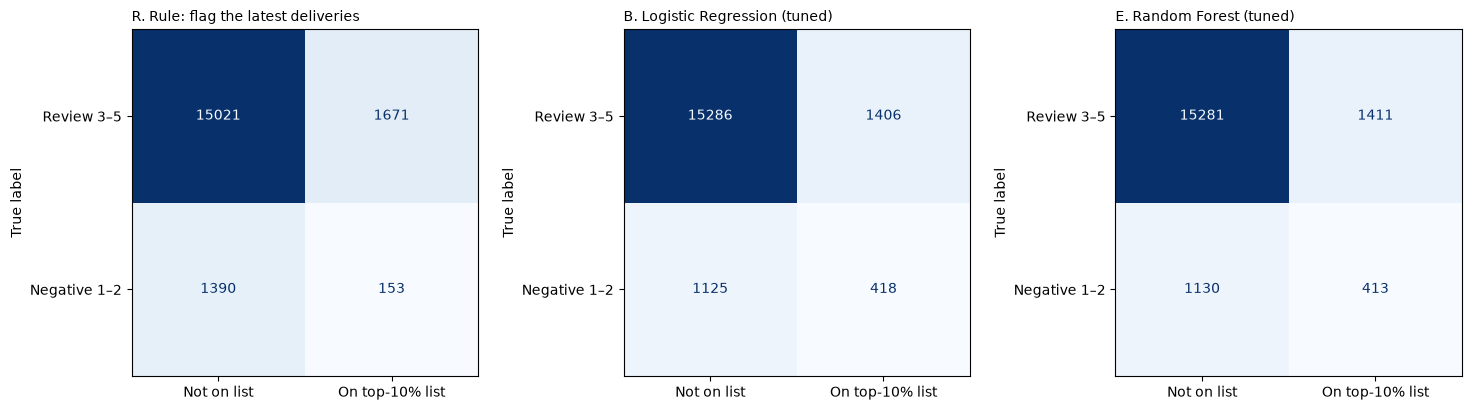

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, name in zip(axes, [RULE, B, E]):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        top_list[name].astype(int),
        display_labels=["Review 3–5", "Negative 1–2"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_xticks([0, 1], ["Not on list", "On top-10% list"])
    ax.set_xlabel("")
    ax.set_title(name, loc="left", fontsize=10)
plt.tight_layout()
plt.show()

### What this tells us

* **The test period has 1,543 negative reviews among 18,235 orders (8.5%)**, so each top-10% list holds 1,824 orders.
* **The models find unhappy customers far better than chance.** The tuned forest's list contains **413 real negative reviews: 22.6% precision**, about **2.7× better** than contacting customers at random (8.5%). It catches 27% of all negative reviews.
* **The rule is no better than random.** Its list contains 153 negative reviews (8.4%), the same as picking orders at random. Without the pre-delivery reviewers, lateness alone hardly separates happy from unhappy customers at delivery.
* **The three main models are tied.** B, D and E find 418, 416 and 413 negative reviews: a difference of 5 customers out of 1,824. The plain Logistic Regression (385) is a little behind, and the single tree (256) far behind.
* **On later orders the tuned Logistic Regression (B) is marginally ahead of the selected forest (E).** Step 13 discusses what this means for the final choice.
* **F1 at the 0.50 cut-off is not a fair comparison here.** The tuned forest gives no test order a score of 0.50 or more, so it flags nobody and its F1 is 0.000. The tuned Logistic Regression uses class weighting, so its scores run higher, and it flags enough orders for an F1 of 0.245. At the same list size (the top 10%) the two are level. That is why Phase 1 chose precision among the top-ranked orders.

### 8.1 ROC and precision-recall curves

**What we are doing:** drawing two curves for every model on the test set. Each curve shows what happens as the contact list grows from the riskiest order to all orders.

* **ROC curve:** for every list size, the share of unhappy customers found (true-positive rate) against the share of happy customers wrongly contacted (false-positive rate). The area under it (**AUC-ROC**) is 1.0 for a perfect ranking, and 0.5 for random guessing (the dashed line).
* **Precision-recall curve:** for every list size, precision (how many on the list are really unhappy) against recall (how many of all unhappy customers the list finds). Random guessing gives a flat line at the negative-review rate. The dots mark the top-10% contact list of the two finalists.

**Why both:** ROC curves are the standard way to compare classifiers, but when the thing we look for is rare (8.5% here), they can look flattering. The precision-recall curve focuses on the unhappy customers, which is what customer service cares about.

> 📌 *"ROC can be overly optimistic when negatives vastly outnumber positives"* (IT5006 T08 tutorial, *Classification Models*)
>
> 📌 *"PR curve focuses on the minority class (what we usually care about)"* (IT5006 T08 tutorial, *Classification Models*)

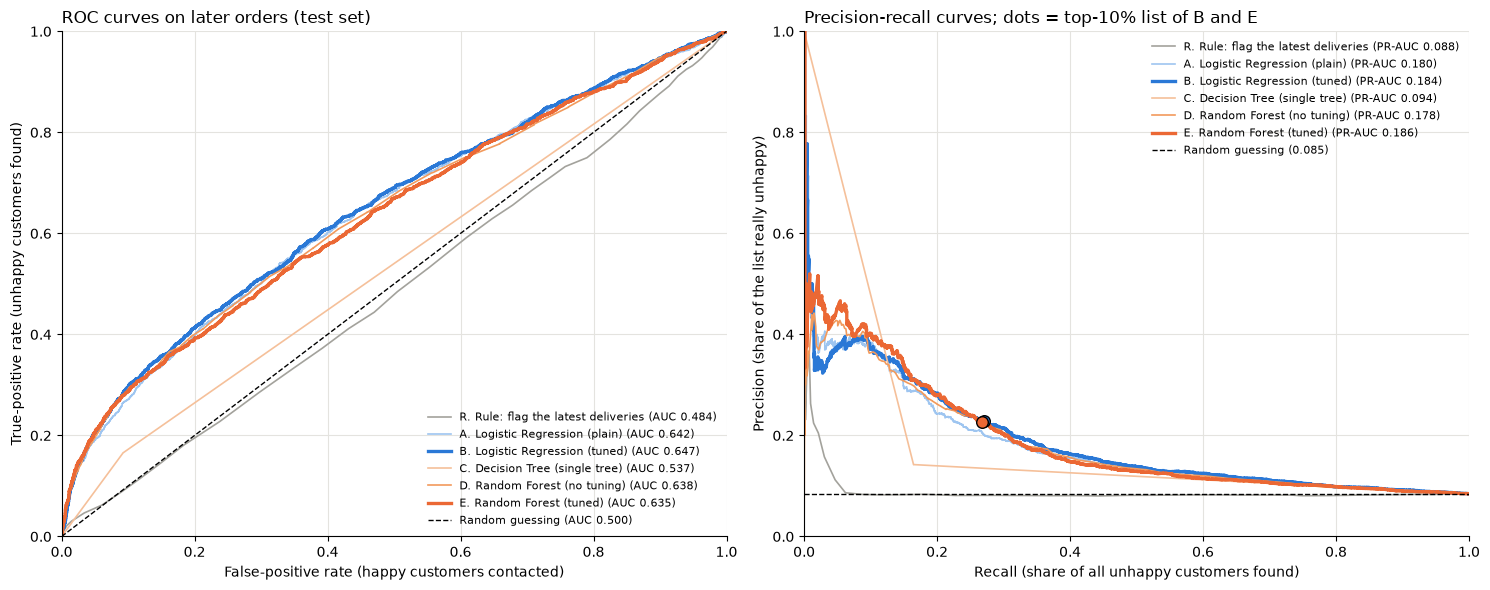

In [14]:
CURVE_STYLE = {
    RULE: ("#a3a29c", 1.2), A: ("#9ec5f0", 1.2), B: ("#2a78d6", 2.4),
    C: ("#f5c09a", 1.2), D: ("#f29a5c", 1.2), E: ("#eb6834", 2.4),
}
fig, (roc_ax, pr_ax) = plt.subplots(1, 2, figsize=(15, 6))
for name in [RULE] + MODELS:
    color, width = CURVE_STYLE[name]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_scores[name])
    roc_ax.plot(false_positive_rate, true_positive_rate, color=color, lw=width,
                label=f"{name} (AUC {test_table.loc[name, 'roc_auc']:.3f})")
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores[name])
    pr_ax.plot(recall_curve, precision_curve, color=color, lw=width,
               label=f"{name} (PR-AUC {test_table.loc[name, 'pr_auc']:.3f})")
for name in [B, E]:
    pr_ax.scatter(test_table.loc[name, "top10_recall"], test_table.loc[name, "top10_precision"],
                  s=70, color=CURVE_STYLE[name][0], edgecolor="black", zorder=5)
roc_ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random guessing (AUC 0.500)")
pr_ax.axhline(y_test.mean(), color="black", linestyle="--", lw=1, label=f"Random guessing ({y_test.mean():.3f})")
roc_ax.set(xlabel="False-positive rate (happy customers contacted)", ylabel="True-positive rate (unhappy customers found)",
           xlim=(0, 1), ylim=(0, 1))
pr_ax.set(xlabel="Recall (share of all unhappy customers found)", ylabel="Precision (share of the list really unhappy)",
          xlim=(0, 1), ylim=(0, 1))
roc_ax.set_title("ROC curves on later orders (test set)", loc="left")
pr_ax.set_title("Precision-recall curves; dots = top-10% list of B and E", loc="left")
for ax in (roc_ax, pr_ax):
    ax.legend(loc="upper right" if ax is pr_ax else "lower right", fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(color="#e4e3df", linewidth=0.8)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### What this tells us

* **AUC-ROC on later orders:** tuned Logistic Regression B 0.647, plain Logistic Regression A 0.642, untuned forest D 0.638, tuned forest E 0.635, single tree C 0.537 and the rule R 0.484. **PR-AUC:** E 0.186, B 0.184, A 0.180, D 0.178, C 0.094 and R 0.088, against 0.085 for random guessing.
* **Tuned Logistic Regression vs tuned Random Forest:** the two finalists are almost level. B has the slightly higher AUC-ROC (0.647 vs 0.635), and E the slightly higher PR-AUC (0.186 vs 0.184). Neither family ranks clearly better.
* **The four main models are about equally good, and modest.** An AUC of about 0.64 means the models put a random unhappy customer above a random happy one about 64% of the time. That is useful for a contact list, but far from perfect.
* **The rule ranks no better than random** (AUC 0.484, PR-AUC about the negative-review rate). In Stage 2, lateness alone does not separate happy from unhappy customers.
* **For a much shorter list, the forest looks better.** At the far left of the precision-recall chart, where only the very riskiest orders are contacted, the tuned forest's curve sits visibly above the tuned Logistic Regression's. The two curves meet around the top-10% point (the dots). If customer service could only handle a few contacts a day, this would favour the forest; the notebook does not measure it exactly.
* **The top-10% list sits at the high-precision end of the curve**, where precision is about 0.23, against 0.085 for random contact. A longer list would find more unhappy customers, but each extra contact would be less likely to be one.

### 8.2 Train vs validation vs test

**What we are doing:** putting three scores side by side for every model:

* **Train:** the score on orders the model **learned from** (averaged over the five practice exams).
* **Validation:** the score on the practice exams it did **not** learn from (step 7).
* **Test:** the score on the final exam (this step).

**Why:** this is the standard check for **overfitting**. A model that is much better on train than on validation has memorised its training orders instead of learning patterns that carry over. Validation and test should be reasonably close; with a time split, some gap is expected because the test period is different.

In [15]:
train_validation_test = pd.DataFrame({
    "train top-10% precision": cv_table["train_top10_precision"],
    "validation top-10% precision": cv_table["top10_precision"],
    "test top-10% precision": test_table["top10_precision"],
    "train F1": cv_table["train_f1"],
    "validation F1": cv_table["f1"],
    "test F1": test_table["f1"],
}).loc[MODELS]
train_validation_test["top-10% gap: train − validation"] = (
    train_validation_test["train top-10% precision"] - train_validation_test["validation top-10% precision"]
)
display(train_validation_test.round(3))

,train top-10% precision,validation top-10% precision,test top-10% precision,train F1,validation F1,test F1,top-10% gap: train − validation
A. Logistic Regression (plain),0.241,0.239,0.211,0.038,0.053,0.053,0.002
B. Logistic Regression (tuned),0.231,0.267,0.229,0.244,0.252,0.245,-0.036
C. Decision Tree (single tree),0.949,0.145,0.140,0.999,0.151,0.153,0.805
D. Random Forest (no tuning),0.949,0.251,0.228,0.999,0.022,0.046,0.698
E. Random Forest (tuned),0.293,0.275,0.226,0.000,0.000,0.000,0.017


### What this tells us

* **Logistic Regression does not overfit.** Its train and validation scores are almost the same (gaps of 0.002 and −0.036).
* **Unrestricted trees memorise.** The single tree (C) and the untuned forest (D) score 0.949 on their training orders (F1 0.999), far above validation (0.145 and 0.251).
* **Tuning tames the forest.** E's train score (0.293) is close to its validation score (0.275), a gap of only 0.017.
* **Every model drops a little from validation to test,** because the test period has fewer unhappy customers (step 3). The tuned forest drops the most (0.275 → 0.226), so on the test set it ends level with the tuned Logistic Regression (0.267 → 0.229) and the untuned forest (0.251 → 0.228).

## Step 9. Does each step up in complexity help, and do the models beat the rule?

**What we are doing:** checking every step up in complexity, plus the most important question of all: does the best model beat the simple rule?

| Step | From (simpler) | To (more complex) | Question |
|---|---|---|---|
| Logistic Regression | A. Plain | B. Tuned | Do regularisation and class weighting help? |
| Tree family, step 1 | C. Single tree | D. Random Forest | Does averaging 200 trees beat one tree? |
| Tree family, step 2 | D. Random Forest | E. Tuned Random Forest | Does tuning the forest help? |
| Model vs rule | R. Rule | The winner from step 7 | Is a model worth building at all? |

**The rule for "worth it":** the more complex option must beat the simpler one on **average top-10% precision** *and* in **at least 4 of the 5 practice exams**. Comparing exam by exam matters here: each exam covers a different period, so a single average can hide that one model only wins in one unusual period.

**Why:** a more complex model is harder to explain and maintain, so it has to earn its place. The project brief asks for exactly this check.

> 📌 *"Any more complex variant must demonstrate improvement over the baseline."* (IT5006 project brief)

Logistic Regression: plain → tuned (A → B): WORTH IT
Tree family: single tree → forest (C → D): WORTH IT
Tree family: forest → tuned forest (D → E): WORTH IT
Best model vs the rule (R → E): WORTH IT


,CV top-10% simpler,CV top-10% more complex,average gain,exams won (of 5),better on test,verdict
step,,,,,,
Logistic Regression: plain → tuned,0.239,0.267,0.028,5,"5 of 5: Top-10% precision, Top-10% recall, F1-Score, AUC-ROC, PR-AUC",Worth it
Tree family: single tree → forest,0.145,0.251,0.106,5,"4 of 5: Top-10% precision, Top-10% recall, AUC-ROC, PR-AUC",Worth it
Tree family: forest → tuned forest,0.251,0.275,0.024,5,1 of 5: PR-AUC,Worth it
Best model vs the rule,0.145,0.275,0.130,5,"4 of 5: Top-10% precision, Top-10% recall, AUC-ROC, PR-AUC",Worth it


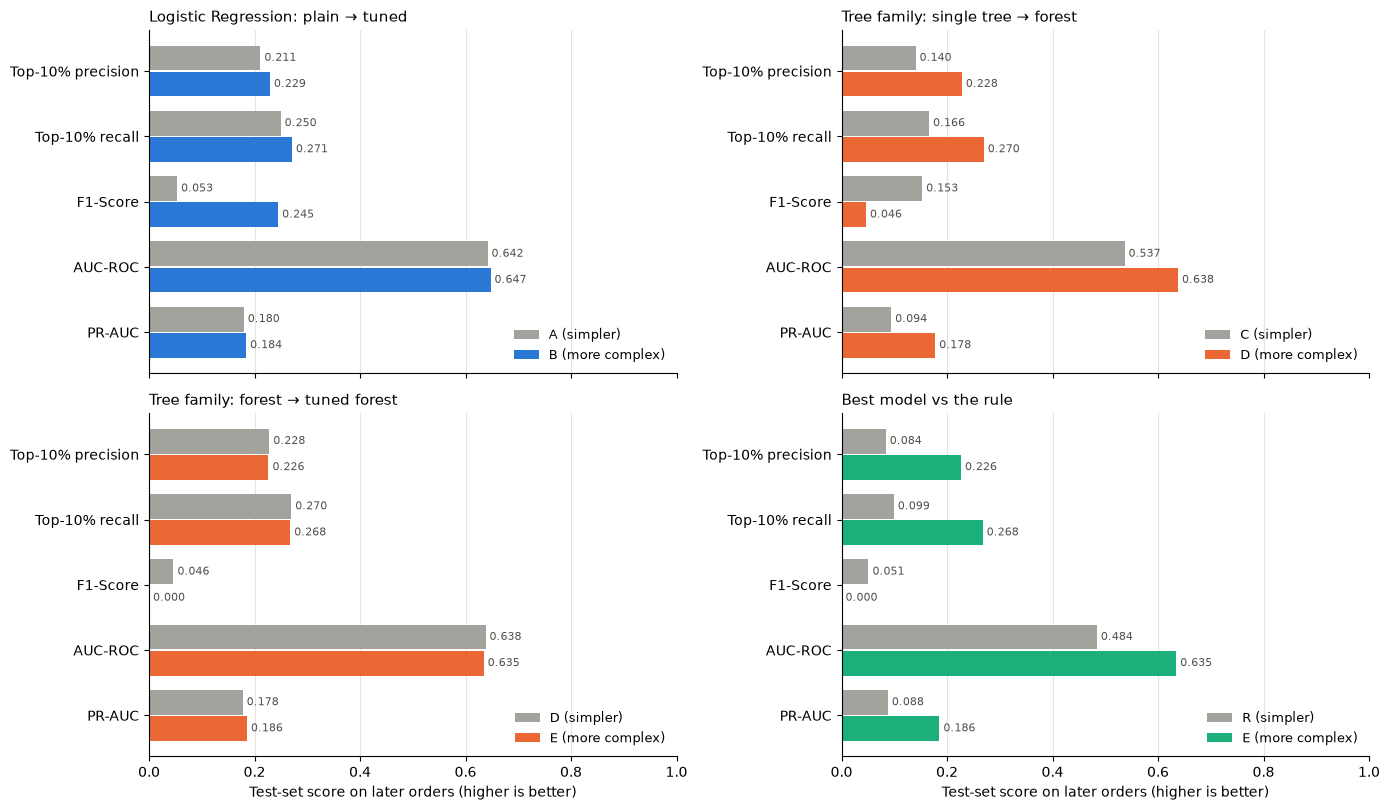

In [16]:
COMPLEXITY_STEPS = [
    ("Logistic Regression: plain → tuned", A, B, "#2a78d6"),
    ("Tree family: single tree → forest", C, D, "#eb6834"),
    ("Tree family: forest → tuned forest", D, E, "#eb6834"),
    ("Best model vs the rule", RULE, FINAL, "#1baf7a"),
]
TEST_METRICS = {"top10_precision": "Top-10% precision", "top10_recall": "Top-10% recall", "f1": "F1-Score", "roc_auc": "AUC-ROC", "pr_auc": "PR-AUC"}

summary_rows = []
for step, simpler, complex_model, _ in COMPLEXITY_STEPS:
    gain = cv_table.loc[complex_model, "top10_precision"] - cv_table.loc[simpler, "top10_precision"]
    exams_won = int((cv_folds[complex_model] > cv_folds[simpler]).sum())
    improved = [label for metric, label in TEST_METRICS.items() if test_table.loc[complex_model, metric] > test_table.loc[simpler, metric]]
    verdict = "Worth it" if gain > 0 and exams_won >= 4 else "Not worth it"
    summary_rows.append({
        "step": step,
        "CV top-10% simpler": cv_table.loc[simpler, "top10_precision"],
        "CV top-10% more complex": cv_table.loc[complex_model, "top10_precision"],
        "average gain": gain,
        "exams won (of 5)": exams_won,
        "better on test": f"{len(improved)} of 5: {', '.join(improved)}",
        "verdict": verdict,
    })
    print(f"{step} ({simpler[:1]} → {complex_model[:1]}): {verdict.upper()}")
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(summary_rows).set_index("step").round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 8.2), sharex=True)
for ax, (step, simpler, complex_model, color) in zip(axes.ravel(), COMPLEXITY_STEPS):
    comparison = pd.DataFrame({
        simpler[:1] + " (simpler)": test_table.loc[simpler, list(TEST_METRICS)],
        complex_model[:1] + " (more complex)": test_table.loc[complex_model, list(TEST_METRICS)],
    }).rename(index=TEST_METRICS)
    positions = np.arange(len(comparison))[::-1]
    for offset, column, bar_color in [(0.2, comparison.columns[0], "#a3a29c"), (-0.2, comparison.columns[1], color)]:
        ax.barh(positions + offset, comparison[column], height=0.38, color=bar_color, label=column)
        for y_position, value in zip(positions + offset, comparison[column]):
            ax.text(value, y_position, f" {value:.3f}", va="center", fontsize=8, color="#52514e")
    ax.set_yticks(positions, comparison.index)
    ax.set_xlim(0, 1)
    ax.set_title(step, loc="left", fontsize=11)
    ax.legend(loc="lower right", frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#e4e3df", linewidth=0.8)
    ax.set_axisbelow(True)
for ax in axes[-1]:
    ax.set_xlabel("Test-set score on later orders (higher is better)")
plt.tight_layout()
plt.show()

### What this tells us

* **All four steps pass the "worth it" rule in cross-validation, each winning all 5 exams:**
  * **Best model vs the rule (R → E): the biggest gain** (+0.130 on average; 0.226 vs 0.084 on later orders). Building a model is clearly worth it.
  * **Single tree → forest (C → D): a large gain** (+0.106). One tree is not good enough; averaging 200 trees fixes it.
  * **Plain → tuned Logistic Regression (A → B): a solid gain** (+0.028), and B is also better on all five test scores (418 vs 385 unhappy customers on the list).
  * **Forest → tuned forest (D → E): a gain in cross-validation only** (+0.024). On later orders the tuned forest is better only on PR-AUC, and its list finds 3 fewer unhappy customers (413 vs 416).
* **What this means:** using a sensible model instead of the rule, and a forest instead of a single tree, clearly pays off. Tuning clearly helps Logistic Regression. For the forest, tuning mainly controls overfitting (next question) rather than improving results on later orders.

**Likely question:** *"Tuning the forest did not help on later orders. Why keep it?"* **Answer:** it was chosen by the rule fixed before the test set was opened, and it wins all five practice exams. It also stops the forest memorising its training orders: the train–validation gap falls from 0.698 to 0.017. A model that memorises less is safer to deploy.

## Step 10. What do the models rely on?

A model that cannot be explained is hard to trust. We look at this from two angles.

> 📌 *"Do not implement many algorithms without depth; clear business interpretation is more important than a long list of poorly tuned models."* (IT5006 project brief)

### 10.1 Logistic Regression weights (tuned model, B)

**What we are doing:** reading the weights of the tuned Logistic Regression.

* A **positive** weight raises the risk; a **negative** weight lowers it.
* The **odds ratio** turns a weight into plain English: 1.5 means about **50% higher odds** of a negative review, and 0.8 means 20% lower odds, with every other input held the same. For numbers, this is per one "typical step" up (one standard deviation).
* `training_orders` shows how many training orders have that category (blank for numbers). A big weight resting on very few orders is fragile.

The first table shows the 10 strongest pushes down and the 10 strongest pushes up. The second shows what tuning did to the **plain** model's (A) five largest weights.

In [17]:
def weight_table(model):
    preprocessor = model.named_steps["preprocessor"]
    encoded = preprocessor.transform(X_train)
    table = pd.DataFrame({
        "input": preprocessor.get_feature_names_out(),
        "weight": model.named_steps["classifier"].coef_[0],
        "training_orders": np.asarray((encoded != 0).sum(axis=0)).ravel().astype(float),
    })
    table["odds_ratio"] = np.exp(table["weight"])
    table.loc[table["input"].isin(DELIVERED_NUMERIC_FEATURES), "training_orders"] = np.nan
    return table[["input", "weight", "odds_ratio", "training_orders"]]


tuned_weights = weight_table(fitted[B])
display(
    pd.concat([tuned_weights.nsmallest(10, "weight"), tuned_weights.nlargest(10, "weight")])
    .drop_duplicates()
    .sort_values("weight")
    .reset_index(drop=True)
    .round(3)
)

plain_weights = weight_table(fitted[A])
largest_plain = plain_weights.loc[plain_weights["weight"].abs().nlargest(5).index]
print("What tuning did to the plain model's five largest weights:")
display(pd.DataFrame({
    "input": largest_plain["input"].to_numpy(),
    "training_orders": largest_plain["training_orders"].to_numpy(),
    "odds_ratio_plain": largest_plain["odds_ratio"].to_numpy(),
    "odds_ratio_tuned": tuned_weights.set_index("input").loc[largest_plain["input"], "odds_ratio"].to_numpy(),
}).round(3))

,input,weight,odds_ratio,training_orders
0,primary_product_category_sports_leisure,-0.114,0.892,5882.0
1,primary_product_category_garden_tools,-0.088,0.916,2820.0
2,primary_product_category_stationery,-0.085,0.918,1669.0
3,purchase_month_2018-05,-0.075,0.928,6377.0
4,customer_state_RS,-0.067,0.935,4177.0
5,primary_product_category_luggage_accessories,-0.060,0.941,836.0
6,seller_state_RS,-0.057,0.945,1415.0
7,customer_state_CE,-0.050,0.951,925.0
8,primary_product_category_books_general_interest,-0.046,0.955,383.0
9,seller_state_MG,-0.046,0.955,6051.0


What tuning did to the plain model's five largest weights:


,input,training_orders,odds_ratio_plain,odds_ratio_tuned
0,primary_product_category_food_drink,172.0,0.106,0.961
1,seller_state_CE,56.0,0.213,0.985
2,primary_product_category_fashion_male_clothing,88.0,3.628,1.040
3,primary_product_category_party_supplies,20.0,3.416,1.009
4,seller_state_PB,21.0,2.697,1.008


### What this tells us

* **Order size and delivery time push risk up most.** The strongest positive weights are all numbers: `item_count` (odds ratio 1.40, so each typical step up in item count raises the odds of a negative review by about 40%), `delivery_days` (1.34) and `seller_count` (1.19).
* **Lateness has almost no weight any more.** `late_delivery_flag` and `days_early` are not among the 20 largest weights. In Stage 2 only about 2% of orders are late, and the most upset late customers (those who reviewed while waiting) are handled by Stage 1.
* **Product categories and states have small effects** (odds ratios 0.89–1.16): for example `computers_accessories` (1.16) and `bed_bath_table` (1.13) raise the risk a little, and `sports_leisure` (0.89) lowers it. Each rests on at least 383 training orders.
* **Tuning fixed a real weakness of the plain model.** Its biggest weights sat on **rare categories**, such as `party_supplies` (20 orders, odds ratio 3.42), `seller_state_PB` (21 orders, 2.70) and `food_drink` (172 orders, 0.11). Tuning's regularisation (`C=0.001`) pulled all five back to almost no effect (0.96–1.04).
* These are **associations, not causes**.

### 10.2 Permutation importance: both finalists side by side

Random Forest has no weights to read, so to compare the two families **like for like** we use **permutation importance** on both.

**What we are doing:** for one input at a time (say `delivery_days`), we **shuffle its values randomly** between test orders, which breaks its link to the outcome, and measure how much the model's ranking quality (PR-AUC) drops. A big drop means the model relies on that input; no drop means it barely uses it. Each input is shuffled 5 times and the drops are averaged.

**Why:** it works the same way for any model, and it uses the original 21 inputs, so it is easy to read.

,logistic_regression_pr_auc_drop,random_forest_pr_auc_drop
item_count,0.0467,0.0295
seller_count,0.0301,0.0190
delivery_days,0.0209,0.0053
primary_product_category,0.0029,0.0039
order_freight_value,-0.0002,0.0029
n_seller_states,0.0014,0.0023
days_early,0.0002,0.0018
product_volume_cm3_mean,0.0001,0.0018
max_installments,0.0009,0.0015
order_item_value,0.0001,0.0011


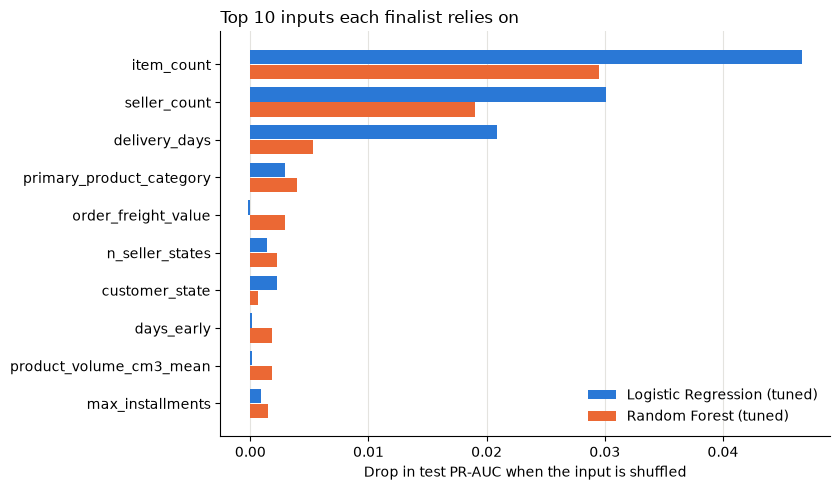

In [18]:
importance_columns = {}
for name in [B, E]:
    result = permutation_importance(
        fitted[name], X_test, y_test, scoring="average_precision", n_repeats=5, random_state=RANDOM_SEED,
    )
    importance_columns[name] = pd.Series(result.importances_mean, index=X_test.columns)

importance_table = (
    pd.DataFrame(importance_columns)
    .rename(columns={B: "logistic_regression_pr_auc_drop", E: "random_forest_pr_auc_drop"})
    .sort_values("random_forest_pr_auc_drop", ascending=False)
)
display(importance_table.round(4))

top = importance_table.loc[importance_table.max(axis=1).nlargest(10).index].iloc[::-1]
positions = np.arange(len(top))
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(positions + 0.2, top["logistic_regression_pr_auc_drop"], height=0.38, color="#2a78d6", label="Logistic Regression (tuned)")
ax.barh(positions - 0.2, top["random_forest_pr_auc_drop"], height=0.38, color="#eb6834", label="Random Forest (tuned)")
ax.set_yticks(positions, top.index)
ax.set_xlabel("Drop in test PR-AUC when the input is shuffled")
ax.set_title("Top 10 inputs each finalist relies on", loc="left")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e4e3df", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### What this tells us

* **Both families agree: order size first, then delivery time.** Logistic Regression relies most on `item_count` (drop 0.047), `seller_count` (0.030) and `delivery_days` (0.021). The Random Forest relies most on `item_count` (0.030), `seller_count` (0.019) and `delivery_days` (0.005). Every other input causes a drop of less than 0.005 for both.
* **Lateness barely matters in Stage 2** (`late_delivery_flag` and `days_early` both 0.002 or less). Lateness is still a strong risk signal, but Stage 1 already uses it at the promised date. What is left at delivery is mostly *how long* the delivery took, not whether it was late.
* **Why order size?** Phase 1 noted that a single Olist order may involve several sellers and arrive in separate shipments, which is a plausible reason, but it is not tested here.
* **Payment, product details, geography and `purchase_month` add almost nothing.** This is consistent with Phase 1, which found that monetary variables barely move review scores and that geography acts through delivery time.
* **Caution:** inputs that overlap (`item_count` and `seller_count`; `delivery_days` and `days_early`) share their importance, so each looks less important on its own than the group is. This shows what the models **rely on**, not what **causes** negative reviews.

## Step 11. Error analysis: where does the model go wrong?

**What we are doing:** an overall score can hide big differences. Here we take the winning model's **top-10% contact list** on the test set and check who is on it, split into groups:

1. **By delivery timing:** from "late by 4+ days" to "early by 7+ days".
2. **By order size:** 1 item vs 2 or more items.
3. **Who we catch, who we miss, and who we contact unnecessarily:** what those orders look like.

**Why:** this shows *where* the model is useful and where it is blind, which matters more to customer service than one average score.

In [19]:
other_finalist = B if FINAL == E else E
final_list = top_list[FINAL]
other_list = top_list[other_finalist]
print(f"Winning model: {FINAL}. Recall of the other finalist ({other_finalist[:1]}) and the rule shown for comparison.")


def segment_report(segment, segment_name):
    frame = pd.DataFrame({
        segment_name: segment, "actual": actual_negative,
        "final": final_list, "other": other_list, "rule": top_list[RULE],
    })
    rows = []
    for value, group in frame.groupby(segment_name, observed=True):
        negatives = group["actual"].sum()
        caught = (group["actual"] & group["final"]).sum()
        rows.append({
            segment_name: value,
            "test orders": len(group),
            "negative-review rate": group["actual"].mean(),
            "share on list": group["final"].mean(),
            "recall (winner)": caught / negatives if negatives else np.nan,
            "precision (winner)": caught / group["final"].sum() if group["final"].sum() else np.nan,
            "negatives missed": int(negatives - caught),
            f"recall ({other_finalist[:1]})": (group["actual"] & group["other"]).sum() / negatives if negatives else np.nan,
            "recall (rule)": (group["actual"] & group["rule"]).sum() / negatives if negatives else np.nan,
        })
    return pd.DataFrame(rows).set_index(segment_name)


timing_labels = ["Late by 4+ days", "Late by 1–3 days", "On the promised day", "Early by 1–6 days", "Early by 7+ days"]
days_early = X_test["days_early"].to_numpy()
timing = pd.Categorical(
    np.select([days_early <= -4, days_early < 0, days_early == 0, days_early < 7], timing_labels[:4], default=timing_labels[4]),
    categories=timing_labels,
    ordered=True,
)
print("1. By delivery timing")
display(segment_report(timing, "delivery timing").round(3))

order_size = pd.Categorical(np.where(X_test["item_count"] >= 2, "2+ items", "1 item"), categories=["1 item", "2+ items"], ordered=True)
print("2. By order size")
display(segment_report(order_size, "order size").round(3))

outcome_labels = [
    "Caught: negative review, on the list",
    "Missed: negative review, not on the list",
    "Unnecessary contact: happy customer, on the list",
    "Correctly left off the list",
]
outcome = pd.Categorical(
    np.select(
        [actual_negative & final_list, actual_negative & ~final_list, ~actual_negative & final_list],
        outcome_labels[:3],
        default=outcome_labels[3],
    ),
    categories=outcome_labels,
    ordered=True,
)
print("3. What caught, missed and unnecessarily contacted orders look like (winning model)")
display(
    X_test.assign(outcome=outcome)
    .groupby("outcome", observed=True)
    .agg(
        orders=("days_early", "size"),
        share_delivered_late=("late_delivery_flag", "mean"),
        median_days_early=("days_early", "median"),
        median_delivery_days=("delivery_days", "median"),
        share_with_2plus_items=("item_count", lambda items: (items >= 2).mean()),
    )
    .round(3)
)

Winning model: E. Random Forest (tuned). Recall of the other finalist (B) and the rule shown for comparison.
1. By delivery timing


,test orders,negative-review rate,share on list,recall (winner),precision (winner),negatives missed,recall (B),recall (rule)
delivery timing,,,,,,,,
Late by 4+ days,57,0.263,0.614,0.733,0.314,4,0.867,1.00
Late by 1–3 days,241,0.133,0.378,0.531,0.187,15,0.531,1.00
On the promised day,344,0.073,0.154,0.200,0.094,20,0.160,1.00
Early by 1–6 days,3677,0.076,0.084,0.158,0.142,235,0.161,0.29
Early by 7+ days,13916,0.086,0.096,0.282,0.251,856,0.284,0.00


2. By order size


,test orders,negative-review rate,share on list,recall (winner),precision (winner),negatives missed,recall (B),recall (rule)
order size,,,,,,,,
1 item,16498,0.070,0.016,0.036,0.158,1107,0.059,0.118
2+ items,1737,0.227,0.900,0.942,0.238,23,0.886,0.046


3. What caught, missed and unnecessarily contacted orders look like (winning model)


,orders,share_delivered_late,median_days_early,median_delivery_days,share_with_2plus_items
outcome,,,,,
"Caught: negative review, on the list",413,0.068,15.0,8.0,0.901
"Missed: negative review, not on the list",1130,0.017,12.0,8.0,0.020
"Unnecessary contact: happy customer, on the list",1411,0.069,13.0,8.0,0.845
Correctly left off the list,15281,0.010,12.0,7.0,0.010


### What this tells us

* **The contact list is essentially a list of multi-item orders.** 90% of orders with 2+ items are on it, against 1.6% of single-item orders, and 90% of the list's hits have 2+ items. Multi-item orders get far more negative reviews (22.7% vs 7.0%).
* **The rest of the list goes to the few late orders.** 61% of orders that were 4+ days late are on the list (73% of their negative reviews caught), and 38% of those 1–3 days late.
* **Single-item orders are the blind spot.** They are 90% of test orders and hold 1,107 of the 1,130 negative reviews the model misses; it catches only 3.6% of their negative reviews. These customers were unhappy for reasons the data does not show, such as product quality, wrong items or seller communication.
* **Unnecessary contacts are mostly multi-item orders too:** 85% of the 1,411 happy customers on the list had 2+ items.
* **Compared with the rule:** the rule catches every negative review on late and on-the-day orders, but almost none on multi-item orders (recall 4.6%, against 94% for the model). The tuned Logistic Regression's list looks very similar to the forest's.
* **What this means for customer service:** at delivery, the clearest warning sign is an order with several items (often from several sellers). Finding unhappy customers on simple, well-delivered orders would need other data, such as returns, complaints or seller ratings.

**Likely question:** *"Is the model just a 'contact every multi-item order' rule?"* **Answer:** largely, yes, and that is a finding in itself. There were 1,737 multi-item test orders, about the same as the 1,824-order list, and their negative-review rate (22.7%) is close to the list's precision (22.6%). The models discovered this pattern from the data without being told. Their advantage is that the risk score also ranks orders *within* and *beyond* that group, so the list can be made longer or shorter to match customer service's capacity.

## Step 12. How much would a random split have flattered the models?

**What we are doing:** re-running every model with the **random, stratified 80/20 split** that the team's earlier notebooks used, with the same settings, and comparing the scores with our time-based results. We also check `purchase_month`, the one input tied to the calendar, by blanking it out for the two finalists on the time-based split.

**Why:** this measures the **temporal leakage** our Phase 1 literature review warned about. If random-split scores are much higher, a random split would have overstated how well the model works on future orders.

In [20]:
X_random_train, X_random_test, y_random_train, y_random_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED,
)
random_rows = {}
for name in MODELS:
    model = clone(fitted[name]).fit(X_random_train, y_random_train)
    scores = model.predict_proba(X_random_test)[:, 1]
    random_rows[name] = evaluate(y_random_test, scores, scores >= THRESHOLD)
random_rows[RULE] = evaluate(y_random_test, rule_scores(X_random_test), rule_flags(X_random_test))
random_table = pd.DataFrame(random_rows).T.loc[[RULE] + MODELS]
print(f"Random split test set: negative-review rate {y_random_test.mean():.1%}; time-based test set: {y_test.mean():.1%}")
display(pd.DataFrame({
    "top-10% precision: time split": test_table["top10_precision"],
    "top-10% precision: random split": random_table["top10_precision"],
    "F1: time split": test_table["f1"],
    "F1: random split": random_table["f1"],
    "AUC-ROC: time split": test_table["roc_auc"],
    "AUC-ROC: random split": random_table["roc_auc"],
}).loc[[RULE] + MODELS].round(3))

print("Effect of blanking out purchase_month (time-based split, finalists only)")
blanked = {"purchase_month": "all months"}
month_rows = {}
for name in [B, E]:
    model = clone(fitted[name]).fit(X_train.assign(**blanked), y_train)
    scores = model.predict_proba(X_test.assign(**blanked))[:, 1]
    month_rows[name] = {
        "top-10% precision with purchase_month": test_table.loc[name, "top10_precision"],
        "top-10% precision without": top_share_precision(y_test, scores),
        "PR-AUC with purchase_month": test_table.loc[name, "pr_auc"],
        "PR-AUC without": average_precision_score(y_test, scores),
    }
display(pd.DataFrame(month_rows).T.round(3))

Random split test set: negative-review rate 9.5%; time-based test set: 8.5%


,top-10% precision: time split,top-10% precision: random split,F1: time split,F1: random split,AUC-ROC: time split,AUC-ROC: random split
R. Rule: flag the latest deliveries,0.084,0.132,0.051,0.075,0.484,0.522
A. Logistic Regression (plain),0.211,0.244,0.053,0.052,0.642,0.660
B. Logistic Regression (tuned),0.229,0.249,0.245,0.251,0.647,0.661
C. Decision Tree (single tree),0.140,0.160,0.153,0.164,0.537,0.538
D. Random Forest (no tuning),0.228,0.262,0.046,0.042,0.638,0.669
E. Random Forest (tuned),0.226,0.258,0.000,0.000,0.635,0.668


Effect of blanking out purchase_month (time-based split, finalists only)


,top-10% precision with purchase_month,top-10% precision without,PR-AUC with purchase_month,PR-AUC without
B. Logistic Regression (tuned),0.229,0.229,0.184,0.184
E. Random Forest (tuned),0.226,0.223,0.186,0.187


### What this tells us

* **A random split would have flattered every model, but only a little.** Top-10% precision on the random split is 0.244–0.262 for the main models, against 0.211–0.229 on later orders. AUC-ROC is also a little higher (0.660–0.669 against 0.635–0.647). Part of the gap is the test period itself, which has fewer negative reviews (8.5% vs 9.5% in the random test set).
* **The random split would have favoured the forest.** On the random split the tuned forest is ahead of the tuned Logistic Regression (0.258 vs 0.249). On later orders it is slightly behind (0.226 vs 0.229). This echoes Kapoor & Narayanan (2023): validation that does not respect time can overstate a complex model's lead over a simple one.
* **The rule also looks better on a random split** (0.132 vs 0.084), probably because late deliveries were more common in the earlier periods that a random test set includes.
* **`purchase_month` adds nothing.** Removing it leaves the tuned Logistic Regression unchanged (0.229) and lowers the forest by only 0.003, so it can be dropped.

## Step 13. Final comparison: tuned Logistic Regression vs tuned Random Forest

**What we are doing:** comparing the best model of each family on every score, with the rule as a reference. The last column names the better finalist on each row (higher is better for all of them).

In [21]:
FINAL_ROWS = {
    "CV top-10% precision (average of 5 exams)": ("cv", "top10_precision"),
    "Test top-10% precision": ("test", "top10_precision"),
    "Test top-10% recall": ("test", "top10_recall"),
    "Test PR-AUC": ("test", "pr_auc"),
    "Test AUC-ROC": ("test", "roc_auc"),
    "Test F1 at the 0.50 cut-off": ("test", "f1"),
    "Test balanced accuracy at the 0.50 cut-off": ("test", "balanced_accuracy"),
}
sources = {"cv": cv_table, "test": test_table}
head_to_head = pd.DataFrame({
    name: {label: sources[source].loc[name, metric] for label, (source, metric) in FINAL_ROWS.items()}
    for name in [B, E, RULE]
})
head_to_head["better finalist"] = np.where(head_to_head[E] > head_to_head[B], "Random Forest", "Logistic Regression")
display(head_to_head.round(3))
print(f"Notebook runtime: {(time.perf_counter() - notebook_started) / 60:.1f} minutes")

,B. Logistic Regression (tuned),E. Random Forest (tuned),R. Rule: flag the latest deliveries,better finalist
CV top-10% precision (average of 5 exams),0.267,0.275,0.145,Random Forest
Test top-10% precision,0.229,0.226,0.084,Logistic Regression
Test top-10% recall,0.271,0.268,0.099,Logistic Regression
Test PR-AUC,0.184,0.186,0.088,Random Forest
Test AUC-ROC,0.647,0.635,0.484,Logistic Regression
Test F1 at the 0.50 cut-off,0.245,0.000,0.051,Logistic Regression
Test balanced accuracy at the 0.50 cut-off,0.601,0.500,0.508,Logistic Regression


Notebook runtime: 16.9 minutes


### What this tells us: the rule selects the tuned Random Forest (E), but the two finalists are tied on later orders

**How it was chosen:** by the rule fixed in step 7, before the test set was opened: the highest average top-10% precision across the five time-ordered practice exams. The tuned Random Forest won (0.275 vs 0.267 for the tuned Logistic Regression), beating it in all five exams.

**What the test set says:** on later orders the two are level, and the tuned Logistic Regression is marginally ahead on most rows of the table above:

* **Top-10% precision:** 0.229 (B) vs 0.226 (E), i.e. 418 vs 413 unhappy customers on a 1,824-order list.
* **AUC-ROC:** 0.647 (B) vs 0.635 (E). **PR-AUC:** 0.184 (B) vs 0.186 (E).
* **F1 and balanced accuracy at the 0.50 cut-off** favour B only because B uses class weighting and E flags nobody at 0.50. This says nothing about ranking (step 8).

**How to read this honestly:** a difference of 5 customers out of 1,824 is too small to matter. Both models rely on the same inputs (step 10) and pick almost the same orders (step 11). So:

1. **Both are clearly worth building over the rule:** about 2.7× better than random contact, while the rule is no better than random.
2. **Neither family ranks clearly better on later orders.**
3. **When performance is tied, the simpler model has real advantages.** Logistic Regression has readable weights, trains in seconds, and its model file is tiny. The Random Forest needs permutation importance to explain it, is slower to train, and its file is much bigger.

**Decision for the team:** keep the tuned Random Forest, as the pre-set rule says, or choose the tuned Logistic Regression because the test set shows no gain from the extra complexity. Both are defensible if the reason is stated. Whichever is chosen, the report should say that the two were tied on later orders.

**Before relying on either:**

* Expect about 23% precision on the Stage 2 contact list in a period like mid-2018, about 2.7× better than random contact.
* The Stage 2 model cannot find unhappy customers on simple, well-delivered orders (step 11).

## Step 14. The whole system on later orders: Stage 1 rule + Stage 2 model

**What we are doing:** scoring the two stages together on the test period, as customer service would run them:

1. **Stage 1:** at the promised date, contact every order that has not arrived (all late orders, including customers who later reviewed before delivery).
2. **Stage 2:** at delivery, contact the selected model's top-10% list.

Some late orders appear in both stages. Customer service would contact them only once, so the table also counts the Stage 2 orders that Stage 1 had not already contacted.

**Why:** the stages answer different questions, and the business cares about the total: how many unhappy customers the whole system reaches, and how many contacts it costs.

In [22]:
test_start = purchase_time.iloc[n_train]
period = all_delivered.loc[all_delivered["purchase_time"] >= test_start]
period_negative = period[TARGET_COLUMN].eq(1).to_numpy()
stage1 = period["late_delivery_flag"].eq(1).to_numpy()
stage2_ids = classification_data["order_id"].iloc[n_train:].to_numpy()[top_list[FINAL]]
stage2 = period["order_id"].isin(stage2_ids).to_numpy()

system_rows = {}
for label, contacted in [
    ("Stage 1: late at the promised date (rule)", stage1),
    (f"Stage 2: top-10% list at delivery ({FINAL[:1]})", stage2),
    ("Stage 2 orders not already contacted in Stage 1", stage2 & ~stage1),
    ("Both stages together", stage1 | stage2),
]:
    caught = int((contacted & period_negative).sum())
    system_rows[label] = {
        "orders contacted": int(contacted.sum()),
        "negative reviews caught": caught,
        "precision": caught / contacted.sum(),
        "share of all negative reviews": caught / period_negative.sum(),
    }
print(f"Test period (orders bought from {test_start.date()}): {len(period):,} delivered orders, {period_negative.sum():,} negative reviews, "
      f"of which {period['reviewed_before_delivery'].sum():,} orders were reviewed before delivery")
display(pd.DataFrame(system_rows).T.round(3))

Test period (orders bought from 2018-05-31): 18,603 delivered orders, 1,806 negative reviews, of which 368 orders were reviewed before delivery


,orders contacted,negative reviews caught,precision,share of all negative reviews
Stage 1: late at the promised date (rule),657.0,308.0,0.469,0.171
Stage 2: top-10% list at delivery (E),1824.0,413.0,0.226,0.229
Stage 2 orders not already contacted in Stage 1,1698.0,385.0,0.227,0.213
Both stages together,2355.0,693.0,0.294,0.384


### What this tells us

* **The test period has 1,806 negative reviews** among 18,603 delivered orders, including 368 orders reviewed before delivery.
* **Stage 1 is the most precise stage.** Its 657 late orders hold 308 negative reviews: **46.9% precision**, and **17.1%** of all negative reviews. That is lower than over the whole data (62.4%, step 2.2) because late deliveries were rarer in mid-2018.
* **Stage 2 adds most of the reach.** Its list of 1,824 orders finds 413 negative reviews, and 385 of them were not already contacted in Stage 1.
* **Together, the two stages reach 693 unhappy customers, 38.4% of all negative reviews,** with 2,355 contacts (29.4% precision). That is about 26 contacts a day over the three-month test period, and about 3× the test period's negative-review rate (1,806 of 18,603 orders, 9.7%).
* **What this means for customer service:** call late orders on the promised date, which is the most reliable signal and comes before the review is written. Then work through the model's list of riskiest deliveries, mostly multi-item orders. About 6 in 10 negative reviews remain out of reach with this data, mostly on simple, well-delivered orders.

## Step 15. A note on the saved model files

The `.pkl` files in `deployment/` (`delivered_order_negative_review_pipeline.pkl` and `delivered_order_random_forest_pipeline.pkl`) were made by the team's earlier notebooks, which used the **random split**, included customers who reviewed before delivery, and chose settings by F1. This notebook does not overwrite them.

**Once the team has agreed the final Stage 2 model (step 13), it should be retrained on the Stage 2 orders and saved again**, so that Phase 3 deploys the model this notebook actually selects. Stage 1 needs no model file: it is a single rule on the promised delivery date.